## Importy


In [1]:
from utils.sinogram import show_sinogram, scan_generate_sinogram
from utils.filter import filter_sinogram
from utils.image_reconstruction import reconstruct_image, show_image

## Wybór zdjęcia


In [2]:
from utils.choose_image import Choose_image
ui = Choose_image()
ui.show()


Dropdown(description='Obraz:', options=('CT_ScoutView-large.jpg', 'CT_ScoutView.jpg', 'Kolo.jpg', 'Kropka.jpg'…

Output()

## Parametry wejściowe


In [3]:
import math
from ipywidgets import interact, IntSlider

img_matrix = ui.img_matrix
img_width = ui.img_width
img_height = ui.img_height


def symuluj_tomograf(n_detectors, n_scans, angle_cov, det_span):
    global N_detectors, N_scans, angle_coverage, distance_between_emiters 
    

    N_detectors = n_detectors
    N_scans = n_scans
    angle_coverage = angle_cov
    distance_between_emiters = det_span/100*math.sqrt(pow(img_width,2)+pow(img_height,2))/N_detectors 
   
    print(f"Liczba detektorów: {n_detectors}")
    print(f"Liczba skanów: {n_scans}")
    print(f"Kąt: {angle_cov}°")
    print(f"Rozpiętość układu emiterów-detektorów: {det_span}% maksymalnego wymiaru obrazu")
    print(f"Dystans między emiterami: {distance_between_emiters:.4f} px")
    

# Tworzenie interaktywnego panelu
interact(
    symuluj_tomograf, 
    n_detectors=IntSlider(min=90, max=720, step=10, value=180),
    n_scans=IntSlider(min=90, max=720, step=10, value=180),
    angle_cov=IntSlider(min=45, max=360, step=5, value=180),
    det_span=IntSlider(min=1, max=100, step=5, value=100)
);

interactive(children=(IntSlider(value=180, description='n_detectors', max=720, min=90, step=10), IntSlider(val…

# Tomograf


## Generowanie sinogramu i obrazu wyjściowego bez pokazania kroków pośrednich


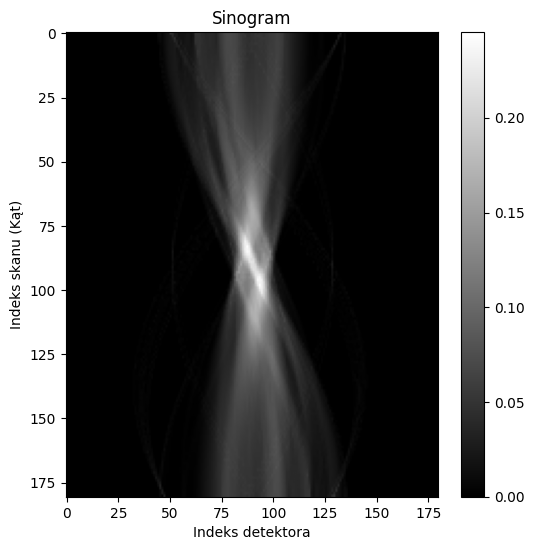

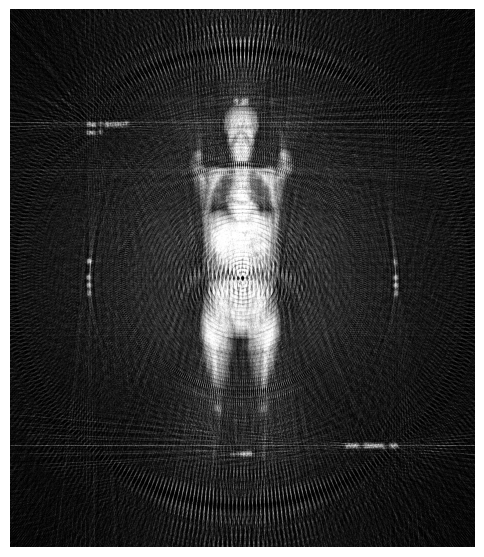

In [4]:
sinogram = scan_generate_sinogram(N_detectors, distance_between_emiters, angle_coverage, N_scans, img_matrix)
filtered_sinogram = filter_sinogram(sinogram)
reconstructed_image_filtered_matrix = reconstruct_image(angle_coverage, img_matrix, N_detectors, distance_between_emiters, N_scans, filtered_sinogram, rescale = True)

show_sinogram(sinogram)
show_image(reconstructed_image_filtered_matrix)

## Generowanie sinogramu i obrazu wyjściowego z krokami pośrednimi


In [5]:
from utils.interactive_tomograph import interactive_tomograph 

interactive_tomograph(img_matrix, N_detectors, distance_between_emiters, angle_coverage,  N_scans)

Trwa prekomputacja pełnego sinogramu. Proszę czekać...
Trwa nakładanie filtru splotowego na sinogram...
Gotowe! Możesz używać suwaka.


interactive(children=(IntSlider(value=0, description='Postęp skanu:', layout=Layout(width='80%'), max=180), Ou…

<function utils.interactive_tomograph.interactive_tomograph.<locals>.update_plot(step)>

## Tworzenie Singoramu


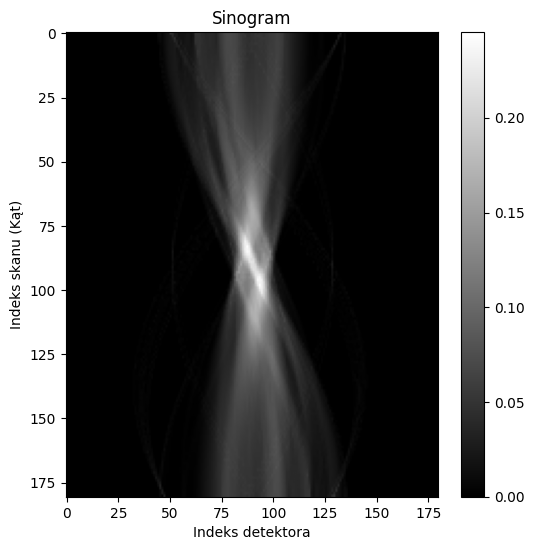

In [6]:
sinogram = scan_generate_sinogram(N_detectors, distance_between_emiters, angle_coverage, N_scans, img_matrix)

show_sinogram(sinogram)

## Filtr


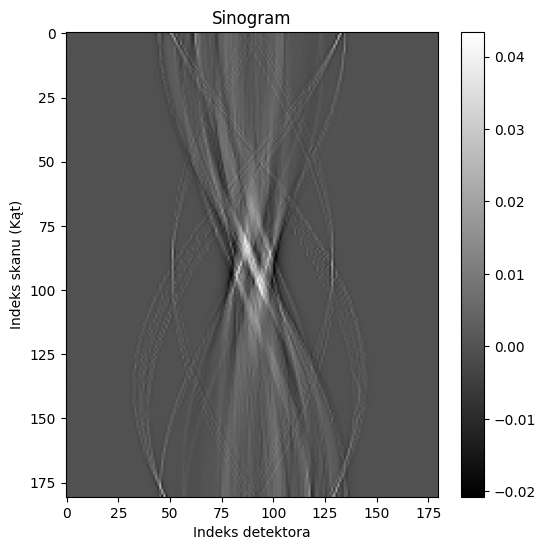

In [7]:
filtered_sinogram = filter_sinogram(sinogram)

show_sinogram(filtered_sinogram)

## Obraz wyjściowy (bez filtra)


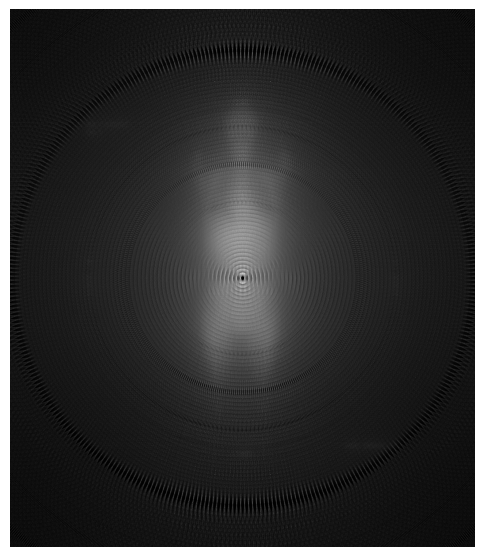

In [8]:
reconstructed_image_NOfilter_matrix = reconstruct_image(angle_coverage, img_matrix, N_detectors, distance_between_emiters, N_scans, sinogram, rescale= False)

show_image(reconstructed_image_NOfilter_matrix)

## Obraz wyjściowy (z filtrem)


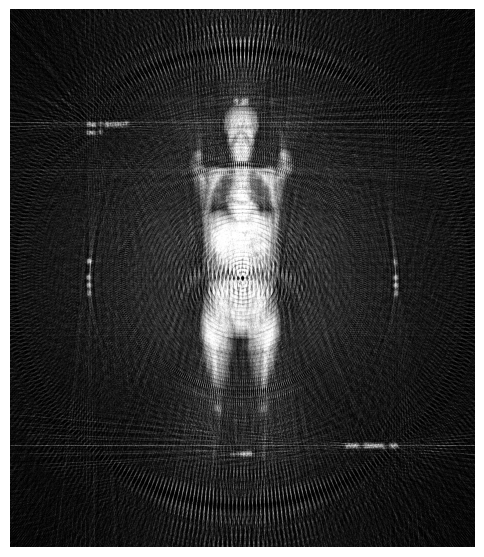

In [9]:
reconstructed_image_filtered_matrix = reconstruct_image(angle_coverage, img_matrix, N_detectors, distance_between_emiters, N_scans, filtered_sinogram, rescale = True)

show_image(reconstructed_image_filtered_matrix)